In [1]:
from astropy.cosmology import FlatLambdaCDM
from astropy.units import Quantity
import numpy as np
import os
import slsim
import slsim.Sources as sources
from astropy.table import vstack
import slsim.Pipelines as pipelines
import slsim.Deflectors as deflectors
from slsim.Lenses.lens_pop import LensPop
from slsim.Sources.SourceCatalogues.QuasarCatalog.quasar_pop import QuasarRate
import matplotlib.pyplot as plt
from slsim.ImageSimulation.image_simulation import (
    point_source_coordinate_properties,
    lens_image_series,
    rgb_image_from_image_list,
)
from slsim.Plots.plot_functions import create_image_montage_from_image_list

# from taufit import fit_drw
from astropy import units as u
import corner

from astropy.table import Table

# roman filters
import speclite
from slsim.Pipelines import roman_speclite

# from slsim.ImageSimulation.roman_image_simulation import simulate_roman_image
from slsim.ImageSimulation.image_simulation import simulate_image

%load_ext autoreload
%autoreload 2

## Configure LSST, Euclid, and Roman Filters

In [2]:
# Import default Euclid, LSST and Roman Space Telescope configuration
path = os.path.dirname(slsim.__file__)
module_path, _ = os.path.split(path)
skypy_config = os.path.join(module_path, "data/SkyPy/roman-lsst-like.yml")

# generate Roman filters
roman_speclite.configure_roman_filters()

# import filter bands and make them recognizable in speclite
# roman_filters = roman_speclite.filter_names()
# filters are ['Roman-F062', 'Roman-F087', 'Roman-F106', 'Roman-F129', 'Roman-F158', 'Roman-F184', 'Roman-F146', 'Roman-F213']


# speclite.filters.load_filters(
#     roman_filters[0],
#     roman_filters[1],
#     roman_filters[2],
#     roman_filters[3],
#     roman_filters[4],
#     roman_filters[5],
#     roman_filters[6],
#     roman_filters[7],
# )

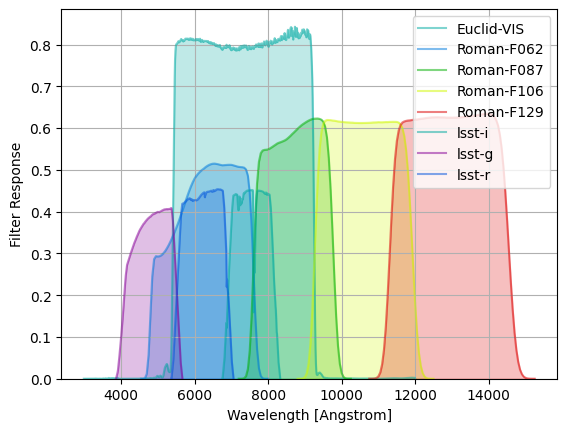

In [3]:
filters = speclite.filters.load_filters(
    "Euclid-VIS",
    "Roman-F062",
    "Roman-F087",
    "Roman-F106",
    "Roman-F129",
    "lsst2016-i",
    "lsst2016-g",
    "lsst2016-r",
)
speclite.filters.plot_filters(filters)

## Lensed quasar population

This notebook shows how to simulate lensed quasar population with variability. For LSST, Euclid and Roman.

In [4]:
# define a cosmology
cosmo = FlatLambdaCDM(H0=70, Om0=0.3)


# define a sky area
galaxy_sky_area = Quantity(value=10, unit="deg2")
quasar_sky_area = Quantity(value=10, unit="deg2")
# full_sky_area = Quantity(value=20000, unit="deg2")


# define limits in the intrinsic deflector and source population (in addition
# to the skypy config
# file)
kwargs_deflector_cut = {"band": "i", "band_max": 28, "z_min": 0.01, "z_max": 2.5}
kwargs_source_cut = {"band": "i", "band_max": 28, "z_min": 0.001, "z_max": 5.0}

In [5]:
# generate galaxy population using skypy pipeline.
galaxy_simulation_pipeline = pipelines.SkyPyPipeline(
    skypy_config=skypy_config,
    sky_area=galaxy_sky_area,
    filters=None,
    cosmo=cosmo,
)

# define host galaxy candidates for the quasars
host_galaxy_candidates = vstack(
    [galaxy_simulation_pipeline.red_galaxies, galaxy_simulation_pipeline.blue_galaxies],
    join_type="exact",
)

In [6]:
# Initiate deflector popiulation class
lens_galaxies = deflectors.AllLensGalaxies(
    red_galaxy_list=galaxy_simulation_pipeline.red_galaxies,
    blue_galaxy_list=galaxy_simulation_pipeline.blue_galaxies,
    kwargs_cut=kwargs_deflector_cut,
    kwargs_mass2light={},
    cosmo=cosmo,
    sky_area=galaxy_sky_area,
    gamma_pl={"mean": 2.078, "std_dev": 0.16},

)
# lens_galaxies = deflectors.EllipticalLensGalaxies(
#     galaxy_list=galaxy_simulation_pipeline.red_galaxies,
#     kwargs_cut=kwargs_deflector_cut,
#     kwargs_mass2light={},
#     cosmo=cosmo,
#     sky_area=galaxy_sky_area,
# )

/home/paras/repos/self/slsim/slsim/Deflectors/DeflectorPopulation/all_lens_galaxies.py:56: UserWarning: Angular size is converted to arcsec because provided input_catalog_type is skypy. If this is not correct, please refer to the documentation of the class you are using
  red_galaxy_list = catalog_with_angular_size_in_arcsec(
/home/paras/repos/self/slsim/slsim/Deflectors/DeflectorPopulation/all_lens_galaxies.py:59: UserWarning: Angular size is converted to arcsec because provided input_catalog_type is skypy. If this is not correct, please refer to the documentation of the class you are using
  blue_galaxy_list = catalog_with_angular_size_in_arcsec(


In [7]:
# Initiate QuasarRate class to generate quasar sample.
quasar_class = QuasarRate(
    skypy_config=skypy_config,
    cosmo=cosmo,
    sky_area=quasar_sky_area,
    noise=True,
    redshifts=np.linspace(0.001, 5.01, 100),  # these redshifts are provided
    # to match general slsim redshift range in skypy pipeline.
    host_galaxy_candidate=host_galaxy_candidates,
    use_qsogen_sed=True,
    qsogen_bands=[
        "F062", "F087", "F106", "F129", "F158", "F184", "F146", "F213", # Roman bands
        "g", "r", "i", "z", "y", # LSST bands
    ],
    use_sed_interpolator = True,
)
quasar_source = quasar_class.quasar_sample(m_min=15, m_max=30, host_galaxy=True)
quasar_source

Matching quasars with host galaxies:   2%|▏         | 2583/105726 [00:01<00:40, 2571.06it/s]/home/paras/repos/self/slsim/slsim/Sources/SourceCatalogues/QuasarCatalog/quasar_host_match.py:123: RuntimeWarning: divide by zero encountered in log10
  M_bol = M_bol_sun - 2.5 * np.log10(L_bol)  # L_sun
Matching quasars with host galaxies: 100%|██████████| 105726/105726 [00:41<00:00, 2568.70it/s]


z,M_i,ps_mag_i,ps_mag_F129,ps_mag_F158,ps_mag_F106,ps_mag_z,ps_mag_y,ps_mag_r,ps_mag_F146,ps_mag_g,ps_mag_F213,ps_mag_F087,ps_mag_F062,ps_mag_F184,M,coeff,ellipticity,physical_size,stellar_mass,angular_size,mag_F062,mag_F087,mag_F106,mag_F129,mag_F158,mag_F184,mag_F146,mag_F213,mag_g,mag_r,mag_i,mag_z,mag_y,vel_disp,black_hole_mass_exponent,eddington_ratio
,,,,,,,,,,,,,,,,,,kpc,,rad,,,,,,,,,,,,,,,,
float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64[5],float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64
2.6733058817920896,-23.156811947270718,22.699280982619257,22.37473439757232,22.425133497690034,22.36413686474274,22.573444400697255,22.406501929096727,22.693717572914217,22.37346014285587,22.867293346032305,22.461793402975704,22.585272275491228,22.735973967611613,22.322730653337633,-20.42721904832209,0.026597281267926657 .. 0.0005795383531159802,0.07175693237899325,2.352564285520465,101744935202.61186,1.4350209375108164e-06,29.031992143761578,28.57596625661924,27.412637971070836,26.259868403896796,25.00822327846396,24.380078705120397,25.346693721106284,24.00568455265983,29.14952096771185,29.07619278099429,28.804297019978563,28.6622532455414,28.175213037863287,145.3259993442451,7.883914046080448,0.47587025934438015
2.213978540095596,-16.910254266382562,28.50540477574676,28.279428461812586,28.19509112229127,28.21243155304709,28.213671540905676,28.246797656976074,28.708691370591556,28.241617464289547,28.637397990035044,27.686453778895686,28.26040187688694,28.632960813317123,28.31821372100844,-16.653434984057895,0.47004979958962895 .. 0.03329953425777659,0.24213196247841223,3.366891753846727,1584686519.4531896,1.9767637842237423e-06,30.044802192073988,29.677498181617707,29.299330239527258,28.61655881475008,28.056378645491776,27.743164081149374,28.333457070557493,27.445647796052725,30.248762960741857,30.037085823787834,29.89523354466924,29.69538875181214,29.430152787456855,39.56533636091753,5.409089409227712,0.45117625501386727
1.0334680339650515,-13.65266976021199,29.96749154582042,29.586668953337835,29.95884212652093,29.959978883106764,30.08219541499331,29.86294184010325,29.932323401535786,29.82677773347934,30.292156005273043,29.707188219635352,30.04375743645541,29.97118764301369,29.9871394010143,-14.234417343212785,0.10396984416633825 .. 0.20243448389185187,0.7141371849919914,0.7812697969551986,32623414.394291952,4.6942489330709793e-07,29.863736902098672,29.228115936496074,29.062326496611284,28.904010796228626,28.86791658180924,28.783067064550714,28.905444586922883,28.751728167181476,30.074355415978246,29.867820048102523,29.56865171815319,29.194635498245567,29.09114240931425,27.693891585705664,4.73049217905121,0.10308969393068228
1.0333885180302627,-16.146258400373494,27.473775785979488,27.105555680019307,27.459322915172436,27.46218594264717,27.57156683284543,27.367431637303287,27.430666663180492,27.334237659959143,27.763981448879665,27.211494918837097,27.53777037729604,27.469587976661852,27.48268812110021,-14.891073022960507,0.12151957511603279 .. 0.10009577178984079,0.6741881527784651,0.9320695517377031,138311403.85967952,5.600141444552946e-07,29.27825000370439,28.580764797836874,28.330072390207444,28.110577881696525,27.964555703911127,27.827903247524706,28.059693570839688,27.715852742317093,29.548262237497067,29.279264220196136,28.966818039168526,28.551774095322646,28.398440870132124,32.10994646412537,5.011931679717066,0.5568437393818894
0.626425179895944,-12.607134219613204,29.839860233204522,29.930583392134594,29.796349070912576,29.503950091394362,29.985476559027873,29.88776031975674,29.944797788581493,29.708536702399854,29.913557621013016,29.48282937955767,29.901387636651588,29.94963579245491,29.657711074301012,-12.925609961534022,0.35755126378098795 .. 0.07450309865948779,0.0254550269850487,0.5605852332353278,14840099.001367167,3.9862

In [8]:
# Initiate source population class.
# source_quasar = sources.PointSources(
#     quasar_source,
#     cosmo=cosmo,
#     sky_area=quasar_sky_area,
#     kwargs_cut=kwargs_source_cut,
#     point_source_type="quasar",
#     point_source_kwargs=kwargs_quasar,
# )

# Point source quasar population with host galaxy
source_quasar = sources.PointPlusExtendedSources(
    point_plus_extended_sources_list=quasar_source,
    cosmo=cosmo,
    sky_area=quasar_sky_area,
    kwargs_cut=kwargs_source_cut,
    list_type="astropy_table",
    catalog_type="skypy",
    point_source_type="quasar",
    extended_source_type="single_sersic",
    point_source_kwargs={},
)

In [10]:
quasar_lens_pop_dummy = LensPop(
    deflector_population=lens_galaxies,
    source_population=source_quasar,
    cosmo=cosmo,
    sky_area=Quantity(value=20000, unit="deg2")
)

In [13]:
# select a random lens and make it simulated image in LSST and Roman bands as an RGB
kwargs_lens_cuts = {
    "min_image_separation": 1,
    # "max_image_separation": 4.0,
    "second_brightest_image_cut": {"i":23.3}
}
quasar_lens_pop_dummy = LensPop(
    deflector_population=lens_galaxies,
    source_population=source_quasar,
    cosmo=cosmo,
    sky_area=Quantity(value=20000, unit="deg2")
)

lens_class = quasar_lens_pop_dummy.select_lens_at_random(
    **kwargs_lens_cuts
)

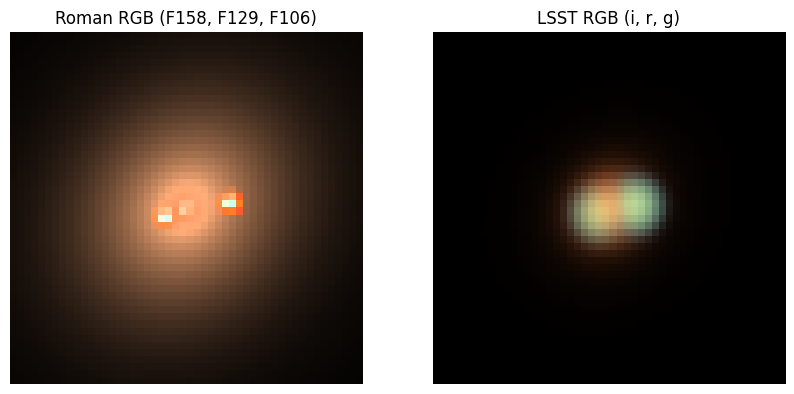

In [14]:


# --- Roman RGB
roman_bands = ["F158", "F129", "F106"]  # RGB: R=F129, G=F106, B=F087
roman_images = []
for band in roman_bands:
    img = simulate_image(
        lens_class=lens_class,
        band=band,
        observatory="Roman",
        num_pix=50,
        add_noise=False,
        with_source=False,
        with_deflector=True,
        with_point_source=True,
    )
    roman_images.append(img)
roman_rgb = rgb_image_from_image_list(roman_images, stretch=0.1)

# --- LSST RGB
lsst_bands = ["i", "r", "g"]  # RGB: R=i, G=r, B=g
lsst_images = []
for band in lsst_bands: 
    img = simulate_image(
        lens_class=lens_class,
        band=band,
        observatory="LSST",
        num_pix=50,
        add_noise=False,
        with_source=False,
        with_deflector=True,
        with_point_source=True,
    )
    lsst_images.append(img)
lsst_rgb = rgb_image_from_image_list(lsst_images, stretch=1)

# plot Roman and LSST RGBs side by side
fig, ax = plt.subplots(1, 2, figsize=(10, 5))
ax[0].imshow(roman_rgb)
ax[0].set_title("Roman RGB (F158, F129, F106)")
ax[0].axis("off")
ax[1].imshow(lsst_rgb)
ax[1].set_title("LSST RGB (i, r, g)")
ax[1].axis("off")
plt.show()

## Draw lenses for LSST

In [ ]:
# Initiate LensPop class to generate lensed quasar pop.
quasar_lens_pop_LSST = LensPop(
    deflector_population=lens_galaxies,
    source_population=source_quasar,
    cosmo=cosmo,
    sky_area=Quantity(value=20000, unit="deg2")
)

In [ ]:
kwargs_lens_cuts_LSST = {
    "min_image_separation": 0.5,  # arcsec
    "max_image_separation": 4,  # arcsec
    # "mag_arc_limit": {"i": 26},
    "second_brightest_image_cut": {"i": 23.3},
}
# drawing population
quasar_lens_population_LSST = quasar_lens_pop_LSST.draw_population(
    speed_factor=1000, kwargs_lens_cuts=kwargs_lens_cuts_LSST
)

/home/paras/sharmapyenv/lib64/python3.12/site-packages/lenstronomy/LensModel/Solver/epl_shear_solver.py:245: RuntimeWarning: invalid value encountered in multiply
  + stuff[1] * 1j
/home/paras/sharmapyenv/lib64/python3.12/site-packages/lenstronomy/LensModel/Solver/epl_shear_solver.py:245: RuntimeWarning: invalid value encountered in multiply
  + stuff[1] * 1j
/home/paras/sharmapyenv/lib64/python3.12/site-packages/lenstronomy/LensModel/Solver/epl_shear_solver.py:245: RuntimeWarning: invalid value encountered in multiply
  + stuff[1] * 1j
/home/paras/sharmapyenv/lib64/python3.12/site-packages/lenstronomy/LensModel/Solver/epl_shear_solver.py:245: RuntimeWarning: invalid value encountered in multiply
  + stuff[1] * 1j
/home/paras/sharmapyenv/lib64/python3.12/site-packages/lenstronomy/LensModel/Solver/epl_shear_solver.py:245: RuntimeWarning: invalid value encountered in multiply
  + stuff[1] * 1j
/home/paras/sharmapyenv/lib64/python3.12/site-packages/lenstronomy/LensModel/Solver/epl_shear_s

In [ ]:
print(f"Total number of lensed quasars: {len(quasar_lens_population_LSST)}")

Total number of lensed quasars: 2655


## Draw lenses for Roman

In [ ]:
quasar_lens_pop_Roman = LensPop(
    deflector_population=lens_galaxies,
    source_population=source_quasar,
    cosmo=cosmo,
    sky_area=Quantity(value=5100, unit="deg2")
)

In [ ]:
kwargs_lens_cuts_Roman = {
    "min_image_separation": 0.2,  # arcsec
    "max_image_separation": 4,  # arcsec
    # "mag_arc_limit": {"i": 26},
    "second_brightest_image_cut": {"F158": 26.2},
}
# drawing population
quasar_lens_population_Roman = quasar_lens_pop_Roman.draw_population(
    speed_factor=1000, kwargs_lens_cuts=kwargs_lens_cuts_Roman
)

/home/paras/sharmapyenv/lib64/python3.12/site-packages/lenstronomy/LensModel/Solver/epl_shear_solver.py:245: RuntimeWarning: invalid value encountered in multiply
  + stuff[1] * 1j
/home/paras/sharmapyenv/lib64/python3.12/site-packages/lenstronomy/LensModel/Solver/epl_shear_solver.py:245: RuntimeWarning: invalid value encountered in multiply
  + stuff[1] * 1j
/home/paras/sharmapyenv/lib64/python3.12/site-packages/lenstronomy/LensModel/Solver/epl_shear_solver.py:245: RuntimeWarning: invalid value encountered in multiply
  + stuff[1] * 1j
/home/paras/sharmapyenv/lib64/python3.12/site-packages/lenstronomy/LensModel/Solver/epl_shear_solver.py:245: RuntimeWarning: invalid value encountered in multiply
  + stuff[1] * 1j
/home/paras/sharmapyenv/lib64/python3.12/site-packages/lenstronomy/LensModel/Solver/epl_shear_solver.py:245: RuntimeWarning: invalid value encountered in multiply
  + stuff[1] * 1j
/home/paras/sharmapyenv/lib64/python3.12/site-packages/lenstronomy/LensModel/Solver/epl_shear_s

In [ ]:
print(f"Total number of lensed quasars: {len(quasar_lens_population_Roman)}")

Total number of lensed quasars: 5569


In [ ]:
survey_stats_dict = {
    "LSST": {
        "name": "LSST",
        "sky_area_deg2": 20000,
        "total_lensed_quasars": len(quasar_lens_population_LSST),
        "quasar_lens_population": quasar_lens_population_LSST,
        "min_image_separation": 0.5,
        "max_image_separation": 4,
        "second_brightest_image_cut": {"i": 23.3},
    },
    "Roman": {
        "name": "Roman (Wide + Medium)",
        "sky_area_deg2": 5100,
        "total_lensed_quasars": len(quasar_lens_population_Roman),
        "quasar_lens_population": quasar_lens_population_Roman,
        "min_image_separation": 0.2,
        "max_image_separation": 4,
        "second_brightest_image_cut": {"F158": 26.2},
    },
}

# add quad and double counts
for survey in survey_stats_dict.keys():
    num_doubles = 0
    num_quads = 0
    for lens_system in survey_stats_dict[survey]["quasar_lens_population"]:
        num_images = lens_system.image_number
        if num_images == [2]:
            num_doubles += 1
        elif num_images == [4]:
            num_quads += 1
    survey_stats_dict[survey]["num_doubles"] = num_doubles
    survey_stats_dict[survey]["num_quads"] = num_quads
    survey_stats_dict[survey]["quad_fraction"] = num_quads / (
        num_doubles + num_quads
    )

print("--------------------------------------------------")
for survey in survey_stats_dict.keys():
    print(f"Survey: {survey_stats_dict[survey]['name']}\n")
    print(f"Sky area (deg^2): {survey_stats_dict[survey]['sky_area_deg2']}")
    print(f"min_image_separation (arcsec): {survey_stats_dict[survey]['min_image_separation']}")
    print(f"max_image_separation (arcsec): {survey_stats_dict[survey]['max_image_separation']}")
    print(f"second_brightest_image_cut: {survey_stats_dict[survey]['second_brightest_image_cut']}")
    print(
        f"Total lensed quasars: {survey_stats_dict[survey]['total_lensed_quasars']}"
    )
    print(f"Number of doubles: {survey_stats_dict[survey]['num_doubles']}")
    print(f"Number of quads: {survey_stats_dict[survey]['num_quads']}")
    print(f"Quad fraction: {survey_stats_dict[survey]['quad_fraction']:.2f}")
    print("--------------------------------------------------")

/home/paras/sharmapyenv/lib64/python3.12/site-packages/lenstronomy/LensModel/Solver/epl_shear_solver.py:245: RuntimeWarning: invalid value encountered in multiply
  + stuff[1] * 1j


--------------------------------------------------
Survey: LSST

Sky area (deg^2): 20000
min_image_separation (arcsec): 0.5
max_image_separation (arcsec): 4
second_brightest_image_cut: {'i': 23.3}
Total lensed quasars: 2655
Number of doubles: 2325
Number of quads: 267
Quad fraction: 0.10
--------------------------------------------------
Survey: Roman (Wide + Medium)

Sky area (deg^2): 5100
min_image_separation (arcsec): 0.2
max_image_separation (arcsec): 4
second_brightest_image_cut: {'F158': 26.2}
Total lensed quasars: 5569
Number of doubles: 5039
Number of quads: 394
Quad fraction: 0.07
--------------------------------------------------


## Make catalogs for LSST and Roman

In [75]:
survey_stats_dict['LSST']["quasar_lens_population"][10].deflector._deflector.__dict__

{'_vel_disp': np.float64(221.48893821094984),
 '_z': np.float64(0.8271273792532163),
 '_stellar_mass': np.float64(350468953026.8204),
 '_deflector_dict': {'M': np.float64(-21.855005183562028),
  'coeff': array([4.08785855e-02, 1.48162343e-05, 1.08933449e-02, 9.47956233e-01,
         2.57020261e-04]),
  'ellipticity': np.float64(0.12124727039361653),
  'physical_size': np.float64(3.9096425625303888),
  'mag_F062': np.float64(22.40417176252032),
  'mag_F087': np.float64(20.768920369081357),
  'mag_F106': np.float64(20.25148227816534),
  'mag_F129': np.float64(19.868084657395713),
  'mag_F158': np.float64(19.552637949524602),
  'mag_F184': np.float64(19.295009075263614),
  'mag_F146': np.float64(19.72606963008902),
  'mag_F213': np.float64(19.188411038787052),
  'mag_g': np.float64(24.026217215212974),
  'mag_r': np.float64(22.563406216232224),
  'mag_i': np.float64(21.443403163435477),
  'mag_z': np.float64(20.71718681256187),
  'mag_y': np.float64(20.465845200843518),
  'galaxy_type': n

In [84]:
# Make a catalog of all lensed quasars across tiers as an astropy table
# Following Properties will be included:
# -----------------------------------------------------------------------------------------------------------------------------
# 'z_S', 'z_D', 'theta_E_arcsec', 'unlensed_ps_mag_<band> for all bands,
# 'sigma_v_D',
# 'num_images', 
# 'lensed_ps_mag_<band>_<image#>' for all bands, depending on number of images (number is from brightest to faintest)
# 'unlensed_host_mag_<band>' for all bands,
# 'lensed_host_mag_<band>' for all bands,
# 'ps_magnification_<image#>' (list of magnifications for all images), (number is from brightest to faintest)
# 'second_brightest_image_ps_mag_<band>' for all bands,
# 'faintest_image_ps_mag_<band>' for all bands,
# 
# 'max_time_delay_days' (time delay between the first and last arriving images in days)
# 'time_delay_<image#>_days' (time delay of each image with respect to the straight line arrival time)
# 'x_image_positions_arcsec_<image#>' (x position of each image in arcsec with respect to the lens center)
# 'y_image_positions_arcsec_<image#>' (y position of each image in arcsec with respect to the lens center)
# 'x_ps_position_arcsec' (x position of point source in arcsec with respect to the lens center)
# 'y_ps_position_arcsec' (y position of point source in arcsec with respect to the lens center)
# 'x_deflector_position_arcsec' (x position of deflector center in arcsec)
# 'y_deflector_position_arcsec' (y position of deflector center in arcsec)
# 'deflector_R_eff_arcsec'
# 'deflector_mag_<band>' for all bands,
# 'deflector_axis_ratio'
# 'deflector_position_angle_deg'
# 'deflector_velocity_dispersion'
# 'deflector_pl_slope'
# 'deflector_mass
# 'external_shear_amplitude'
# 'external_shear_position_angle_deg'
# 'external_convergence'
# 
# -----------------------------------------------------------------------------------------------------------------------------

all_bands = ['g', 'r', 'i', 'z', 'y', 'F062', 'F087', 'F106', 'F129', 'F158', 'F184', 'F146', 'F213']

for survey in survey_stats_dict.keys():
    quasar_lens_population = survey_stats_dict[survey]["quasar_lens_population"]
    table_dict = {
        "z_S": [],
        "z_D": [],
        "theta_E_arcsec": [],
        "sigma_v_D": [],
        "num_images": [],
        "max_time_delay_days": [],
        "deflector_R_eff_arcsec": [],
    }

    for band in all_bands:
        table_dict[f"unlensed_ps_mag_{band}"] = []
        table_dict[f"unlensed_host_mag_{band}"] = []
        table_dict[f"lensed_host_mag_{band}"] = []
        table_dict[f"deflector_mag_{band}"] = []
        table_dict[f"brightest_image_ps_mag_{band}"] = []
        table_dict[f"second_brightest_image_ps_mag_{band}"] = []
        table_dict[f"faintest_image_ps_mag_{band}"] = []
        for img_num in range(1, 5):  # assuming max 4 images
            table_dict[f"lensed_ps_mag_{band}_{img_num}"] = []
            table_dict[f"ps_magnification_{img_num}"] = []

    for lens_system in quasar_lens_population:
        num_images = lens_system.image_number[0]

        table_dict["z_S"].append(lens_system.source_redshift_list[0])
        table_dict["z_D"].append(lens_system.deflector_redshift)
        table_dict["theta_E_arcsec"].append(lens_system.einstein_radius[0])
        table_dict["num_images"].append(num_images)
        table_dict["sigma_v_D"].append(lens_system.deflector_velocity_dispersion())
        table_dict["deflector_R_eff_arcsec"].append(lens_system.deflector.angular_size_light)

        # calculate max time delay in days
        arrival_times = lens_system.point_source_arrival_times()[0]  # in days
        max_time_delay = np.max(arrival_times) - np.min(arrival_times)
        table_dict["max_time_delay_days"].append(max_time_delay)

        # point source magnifications for all images
        ps_magnifications = lens_system.point_source_magnification()[0]
        for img_num in range(1, 5):  # assuming max 4 images
            if img_num <= num_images:
                table_dict[f"ps_magnification_{img_num}"].append(ps_magnifications[img_num-1])
            else:
                table_dict[f"ps_magnification_{img_num}"].append(np.nan)

        # unlensed and lensed magnitudes for all available bands
        for band in all_bands:
            unlensed_ps_mag = lens_system.point_source_magnitude(band=band, lensed=False)[0]
            lensed_ps_mags = lens_system.point_source_magnitude(band=band, lensed=True)[0]

            brightest_image_ps_mag = np.min(lensed_ps_mags)
            second_brightest_image_ps_mag = np.sort(lensed_ps_mags)[1]
            faintest_image_ps_mag = np.max(lensed_ps_mags)

            unlensed_host_mag = lens_system.extended_source_magnitude(band=band, lensed=False)[0]
            lensed_host_mag = lens_system.extended_source_magnitude(band=band, lensed=True)[0]

            deflector_mag = lens_system.deflector_magnitude(band=band)
            
            table_dict[f"unlensed_ps_mag_{band}"].append(unlensed_ps_mag)
            table_dict[f"unlensed_host_mag_{band}"].append(unlensed_host_mag)
            table_dict[f"lensed_host_mag_{band}"].append(lensed_host_mag)
            table_dict[f"brightest_image_ps_mag_{band}"].append(brightest_image_ps_mag)
            table_dict[f"second_brightest_image_ps_mag_{band}"].append(second_brightest_image_ps_mag)
            table_dict[f"faintest_image_ps_mag_{band}"].append(faintest_image_ps_mag)
            table_dict[f"deflector_mag_{band}"].append(deflector_mag)


            for img_num in range(1, 5):  # assuming max 4 images
                if img_num <= num_images:
                    table_dict[f"lensed_ps_mag_{band}_{img_num}"].append(lensed_ps_mags[img_num-1])
                else:
                    table_dict[f"lensed_ps_mag_{band}_{img_num}"].append(np.nan)
    
    # Create astropy table
    lensed_quasar_catalog = Table(table_dict)
    survey_stats_dict[survey]["lensed_quasar_catalog"] = lensed_quasar_catalog
# -----------------------------------------------------------------------------------------------------------------------------

/home/paras/sharmapyenv/lib64/python3.12/site-packages/lenstronomy/LensModel/Solver/epl_shear_solver.py:245: RuntimeWarning: invalid value encountered in multiply
  + stuff[1] * 1j
/home/paras/sharmapyenv/lib64/python3.12/site-packages/lenstronomy/LensModel/Solver/epl_shear_solver.py:245: RuntimeWarning: invalid value encountered in multiply
  + stuff[1] * 1j


Text(0.5, 0.98, 'Lensed Quasars in LSST vs Roman ($\\gamma_{pl}$ = 2.078, $\\sigma_{\\gamma_{pl}}$ = 0.16)')

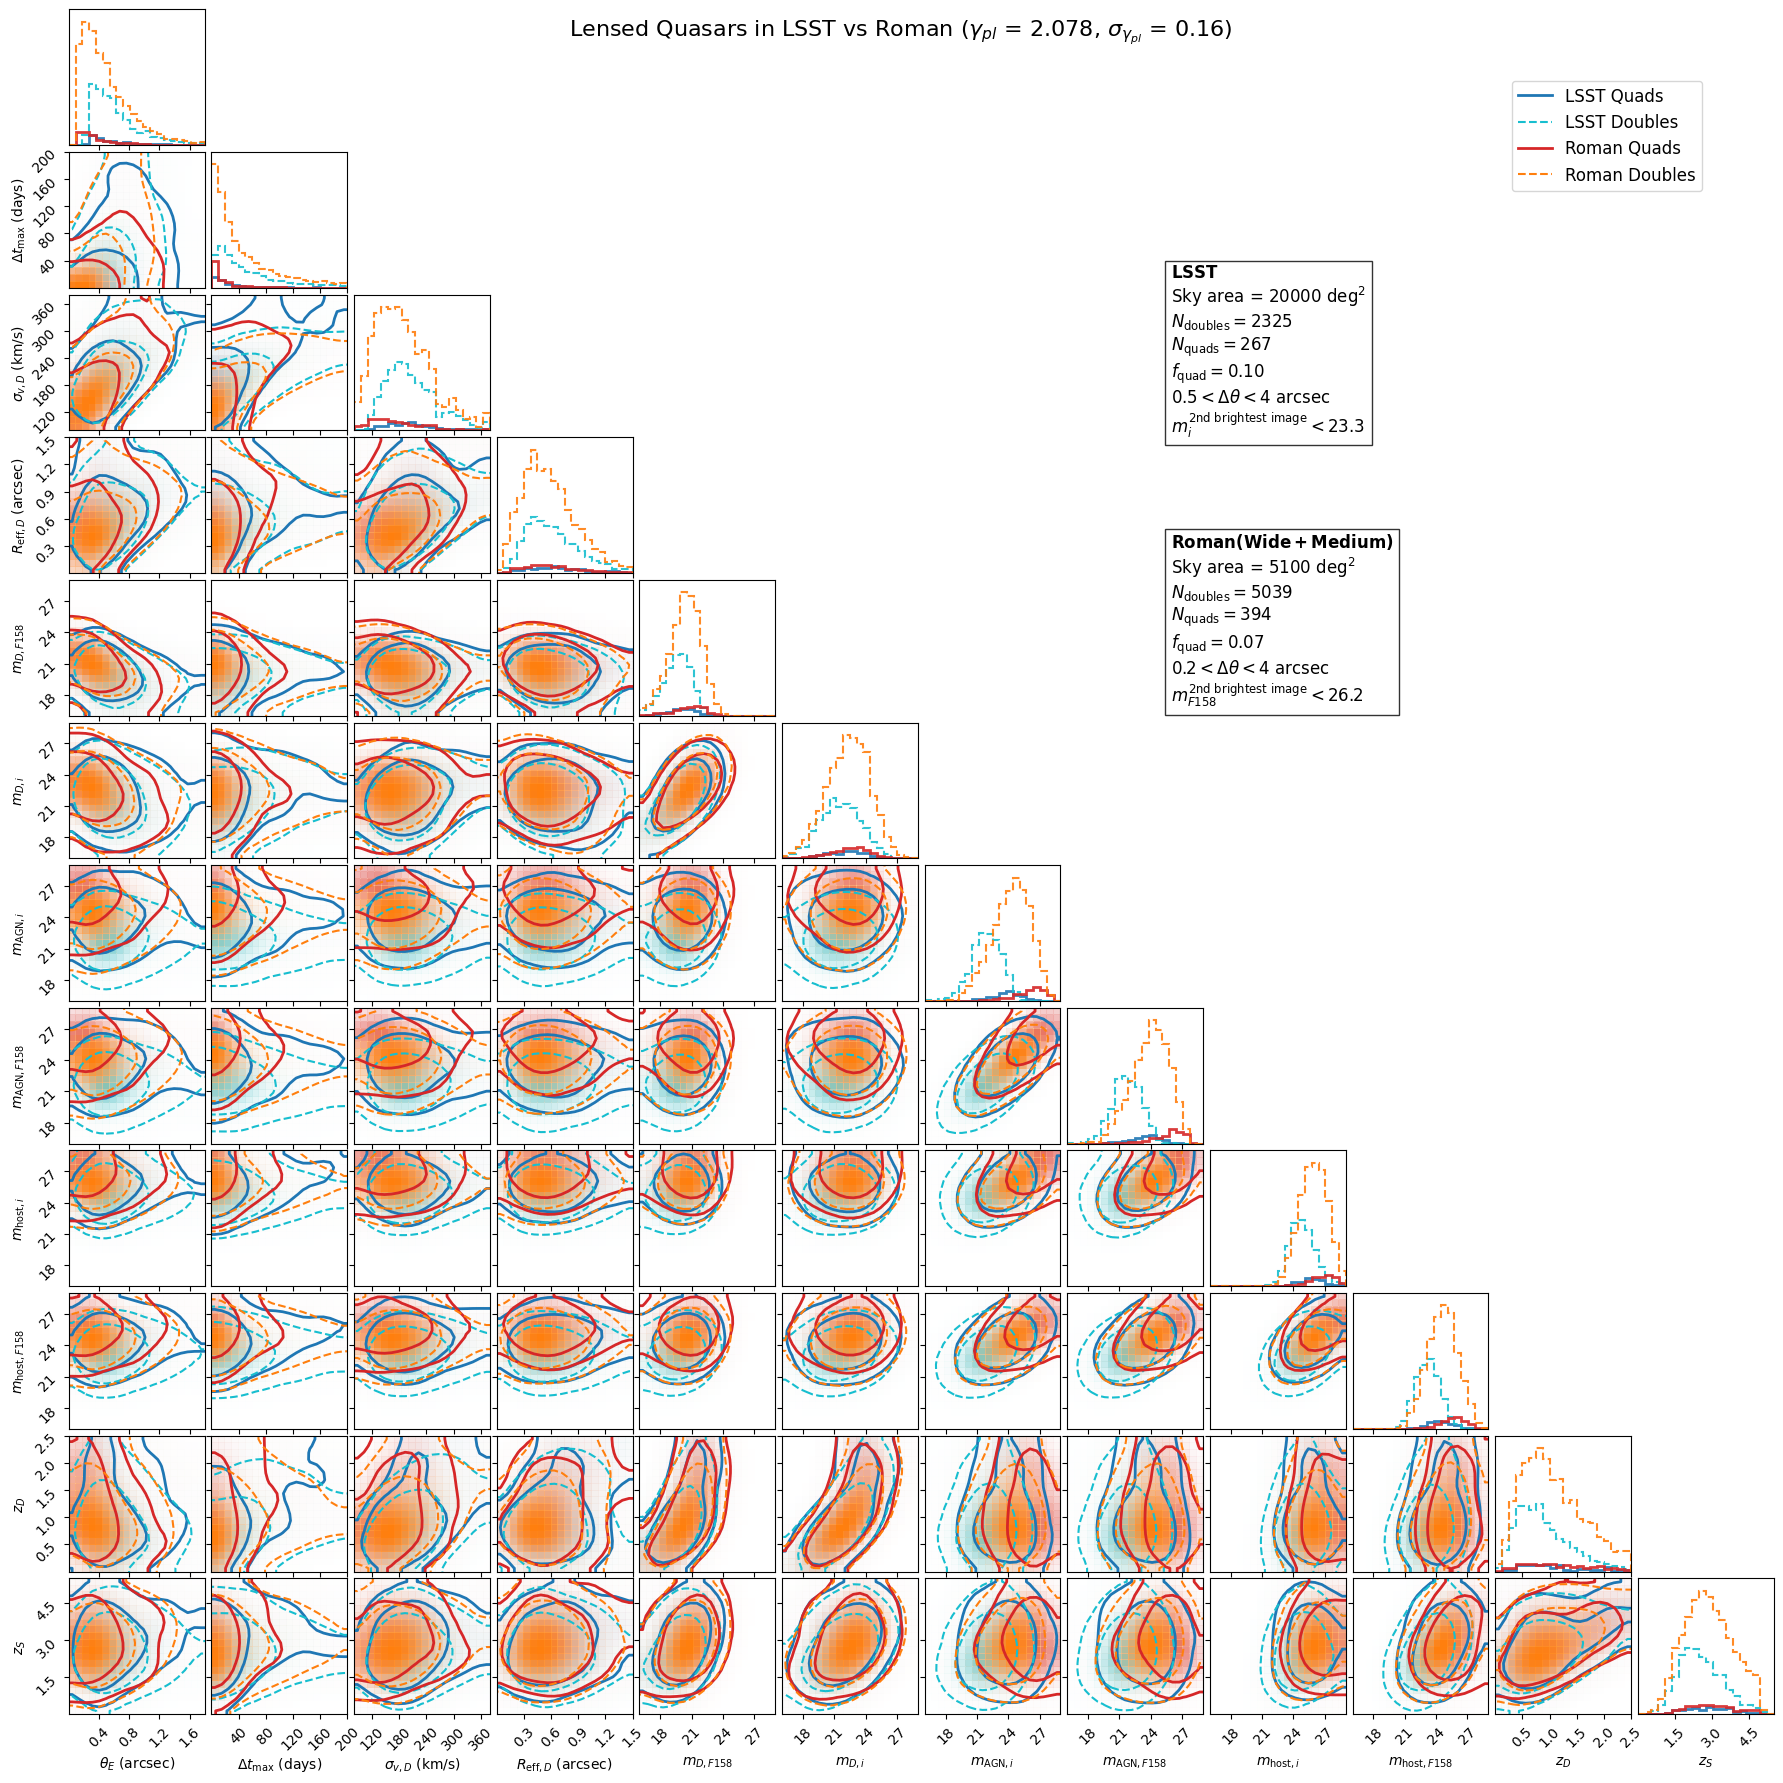

In [88]:
# Now for each survey, we have a lensed quasar catalog in survey_stats_dict[survey]["lensed_quasar_catalog"]
# Now we make a corner plot between z_S, z_D, theta_E_arcsec, sigma_v_D, ....
import corner
import matplotlib.lines as mlines

params = ['theta_E_arcsec', 'max_time_delay_days', 'sigma_v_D', 'deflector_R_eff_arcsec', 'deflector_mag_F158', 'deflector_mag_i', 'unlensed_ps_mag_i', 'unlensed_ps_mag_F158', 'unlensed_host_mag_i', 'unlensed_host_mag_F158', 'z_D', 'z_S', ]
latex_labels = [r'$\theta_E$ (arcsec)', r'$\Delta t_{\max}$ (days)', r'$\sigma_{v, D}$ (km/s)', r'$R_{\mathrm{eff}, D}$ (arcsec)', r'$m_{D, F158}$', r'$m_{D, i}$', r'$m_{\mathrm{AGN}, i}$', r'$m_{\mathrm{AGN}, F158}$', r'$m_{\mathrm{host}, i}$', r'$m_{\mathrm{host}, F158}$', r'$z_D$', r'$z_S$']

figure = plt.figure(figsize=(18, 18))

handles = []
labels = []

range_vals = {
    'theta_E_arcsec': (0, 1.8),
    'sigma_v_D': (80, 380),
    'deflector_mag_F158': (16, 29),
    'deflector_mag_i': (16, 29),
    'unlensed_ps_mag_i': (16, 29),
    'unlensed_ps_mag_F158': (16, 29),
    'unlensed_host_mag_i': (16, 29),
    'unlensed_host_mag_F158': (16, 29),
    'z_D': (0, 2.5),
    'z_S': (0, 5.5),
    'deflector_R_eff_arcsec': (0, 1.5),
    'max_time_delay_days': (0, 200),
}

color_map = {
    "LSST": {"quads": "tab:blue", "doubles": "tab:cyan"},
    "Roman":   {"quads": "tab:red",  "doubles": "tab:orange"},
}

for survey in survey_stats_dict.keys():
    sub_catalog = survey_stats_dict[survey]["lensed_quasar_catalog"].copy()

    sub_catalog_doubles = sub_catalog[sub_catalog['num_images'] == 2]
    sub_catalog_quads = sub_catalog[sub_catalog['num_images'] == 4]


    # quads 
    c_quad = color_map[survey]["quads"]
    data_quads = np.array([sub_catalog_quads[param] for param in params]).T

    if len(data_quads) > 0:
        corner.corner(
            data_quads,
            range=[range_vals[param] for param in params],
            labels=latex_labels,
            color=c_quad,
            fig=figure,
            plot_datapoints=False,
            # using density=True makes distributions comparable even if total counts differ
            hist_kwargs={"density": False, "histtype": "step", "linewidth": 2, "alpha": 0.9},
            contour_kwargs={"linewidths": 2}, 
            smooth=2,
            no_fill_contours=True,
            levels=[0.68, 0.95],
        )
        # Add Handle for Quads
        handles.append(mlines.Line2D([], [], color=c_quad, linewidth=2, label=f'{survey} Quads'))


    # doubles 
    c_double = color_map[survey]["doubles"]
    data_doubles = np.array([sub_catalog_doubles[param] for param in params]).T

    if len(data_doubles) > 0:
        corner.corner(
            data_doubles,
            range=[range_vals[param] for param in params],
            labels=latex_labels,
            color=c_double,
            fig=figure,
            plot_datapoints=False,
            # Dashed lines for doubles to add extra visual distinction
            hist_kwargs={"density": False, "histtype": "step", "linewidth": 1.5, "linestyle": "--", "alpha": 0.9},
            contour_kwargs={"linewidths": 1.5, "linestyles": "--"}, 
            smooth=2,
            no_fill_contours=True,
            levels=[0.68, 0.95],
        )
        # Add Handle for Doubles
        handles.append(mlines.Line2D([], [], color=c_double, linestyle='--', linewidth=1.5, label=f'{survey} Doubles'))

# append the number/cuts information text in empty space with latex formatting
# LSST Survey String
lsst_str = '\n'.join((
    fr'$\bf{{{survey_stats_dict["LSST"]["name"]}}}$',
    fr'Sky area = {survey_stats_dict["LSST"]["sky_area_deg2"]} deg$^2$',
    fr'$N_{{\mathrm{{doubles}}}}={survey_stats_dict["LSST"]["num_doubles"]}$',
    fr'$N_{{\mathrm{{quads}}}}={survey_stats_dict["LSST"]["num_quads"]}$',
    fr'$f_{{\mathrm{{quad}}}}={survey_stats_dict["LSST"]["quad_fraction"]:.2f}$',
    fr'${survey_stats_dict["LSST"]["min_image_separation"]} < \Delta\theta < {survey_stats_dict["LSST"]["max_image_separation"]}$ arcsec',
    fr'$m^{{\mathrm{{2nd\ brightest\ image}}}}_{{i}} < {survey_stats_dict["LSST"]["second_brightest_image_cut"]["i"]}$',
))

# Roman Survey String
roman_str = '\n'.join((
    fr'$\bf{{{survey_stats_dict["Roman"]["name"]}}}$',
    fr'Sky area = {survey_stats_dict["Roman"]["sky_area_deg2"]} deg$^2$',
    fr'$N_{{\mathrm{{doubles}}}}={survey_stats_dict["Roman"]["num_doubles"]}$',
    fr'$N_{{\mathrm{{quads}}}}={survey_stats_dict["Roman"]["num_quads"]}$',
    fr'$f_{{\mathrm{{quad}}}}={survey_stats_dict["Roman"]["quad_fraction"]:.2f}$',
    fr'${survey_stats_dict["Roman"]["min_image_separation"]} < \Delta\theta < {survey_stats_dict["Roman"]["max_image_separation"]}$ arcsec',
    fr'$m^{{\mathrm{{2nd\ brightest\ image}}}}_{{F158}} < {survey_stats_dict["Roman"]["second_brightest_image_cut"]["F158"]}$',
))

figure.text(0.65, 0.75, lsst_str, fontsize=12, color='black', bbox=dict(facecolor='white', alpha=0.8, edgecolor='black'))
figure.text(0.65, 0.60, roman_str, fontsize=12, color='black', bbox=dict(facecolor='white', alpha=0.8, edgecolor='black'))




# legend
figure.legend(handles=handles, loc='upper right', fontsize=12, bbox_to_anchor=(0.95, 0.95))
figure.suptitle(f'Lensed Quasars in LSST vs Roman ($\\gamma_{{pl}}$ = 2.078, $\\sigma_{{\\gamma_{{pl}}}}$ = 0.16)', fontsize=16)

In [189]:
survey_stats_dict['LSST']["detailed_lensed_quasar_catalog"]['external_shear_amplitude']

0.020656643397493138
0.05251369441926224
0.031411593167066036
0.027992857101911857
0.0
0.028237808157090656
0.025162632860580236
0.0
0.02557899041826099
0.0032354922283625354
0.046765151707844295


Text(0.5, 0.98, 'Lensed Quasars in LSST vs Roman ($\\gamma_{pl}$ = 2.078, $\\sigma_{\\gamma_{pl}}$ = 0.16)')

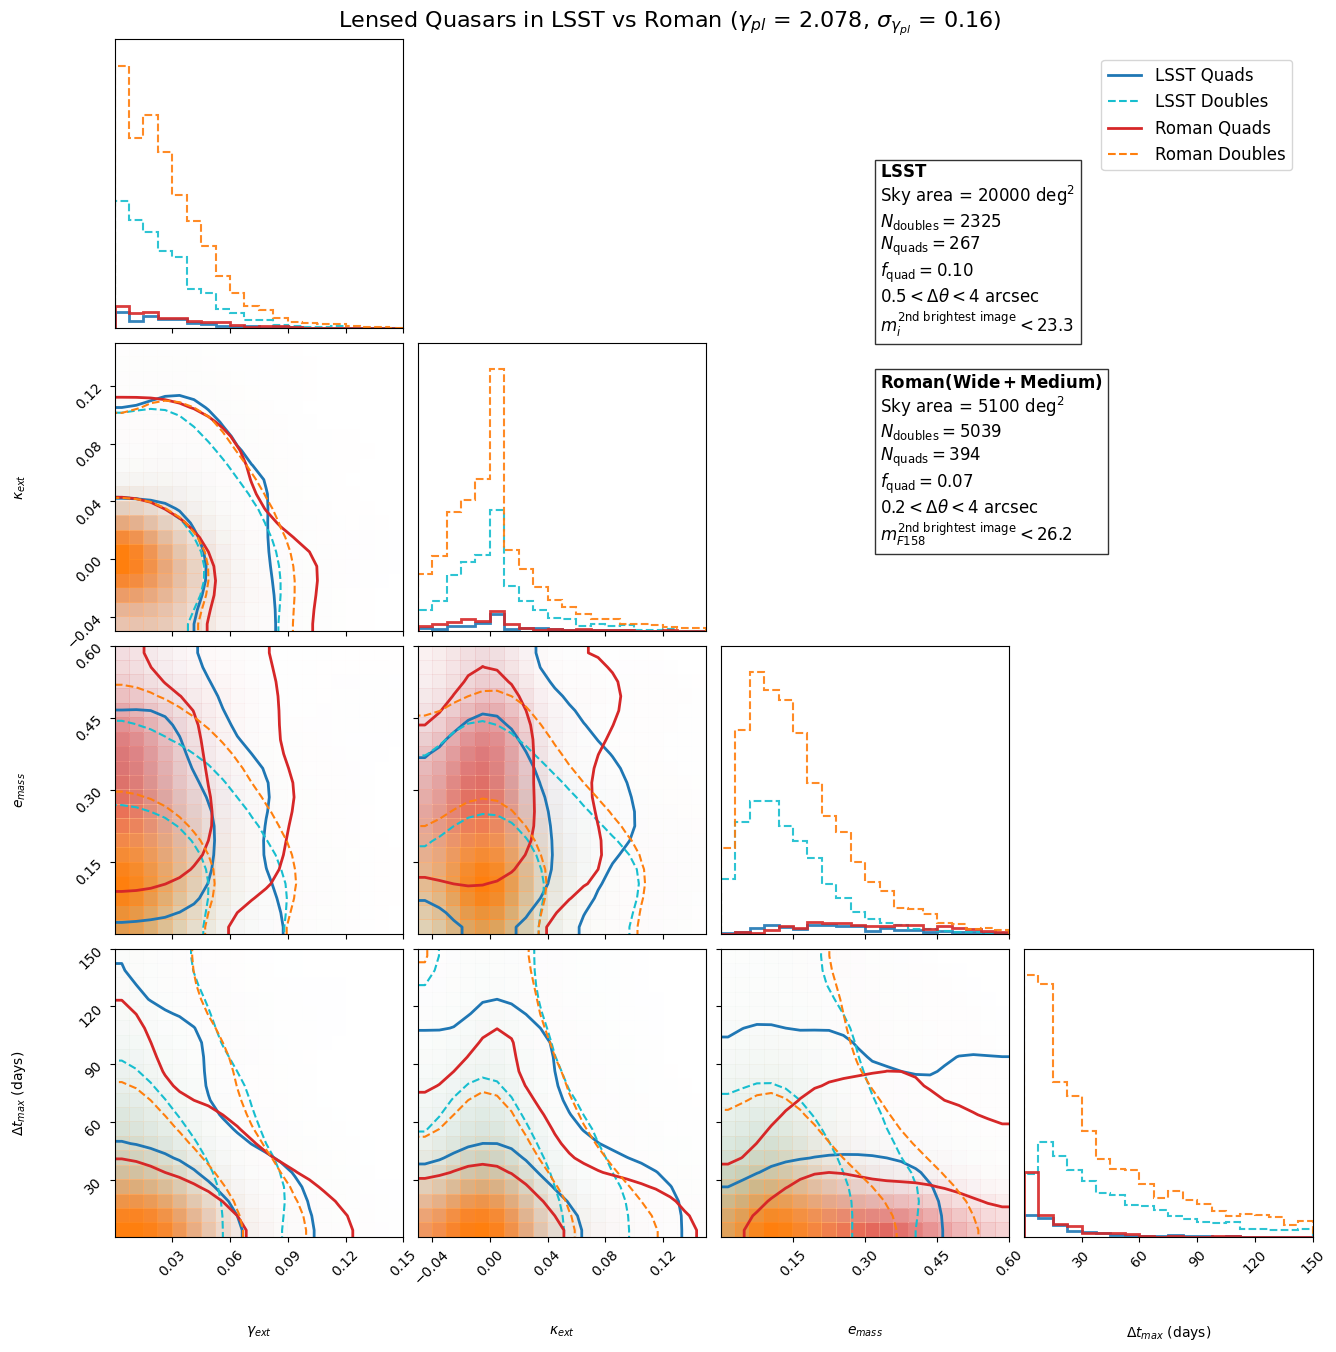

In [ ]:
# --- PHYSICAL CASE 2: ENVIRONMENT ---
params = ['external_shear_amplitude', 'external_convergence', 'deflector_mass_ellipticity', 'max_time_delay_days']
latex_labels = [r'$\gamma_{ext}$', r'$\kappa_{ext}$', r'$e_{mass}$', r'$\Delta t_{max}$ (days)']

range_vals = {
    'external_shear_amplitude': (0, 0.15),
    'external_convergence': (-0.05, 0.15),
    'deflector_mass_ellipticity': (0, 0.6),
    'max_time_delay_days': (0, 150),
}

figure = plt.figure(figsize=(14, 14))

handles = []
labels = []


color_map = {
    "LSST": {"quads": "tab:blue", "doubles": "tab:cyan"},
    "Roman":   {"quads": "tab:red",  "doubles": "tab:orange"},
}

for survey in survey_stats_dict.keys():
    sub_catalog = survey_stats_dict[survey]["detailed_lensed_quasar_catalog"].copy()

    sub_catalog_doubles = sub_catalog[sub_catalog['num_images'] == 2]
    sub_catalog_quads = sub_catalog[sub_catalog['num_images'] == 4]

    # quads 
    c_quad = color_map[survey]["quads"]
    data_quads = np.array([sub_catalog_quads[param] for param in params]).T

    if len(data_quads) > 0:
        corner.corner(
            data_quads,
            range=[range_vals[param] for param in params],
            labels=latex_labels,
            color=c_quad,
            fig=figure,
            plot_datapoints=False,
            # using density=True makes distributions comparable even if total counts differ
            hist_kwargs={"density": False, "histtype": "step", "linewidth": 2, "alpha": 0.9},
            contour_kwargs={"linewidths": 2}, 
            smooth=2,
            no_fill_contours=True,
            levels=[0.68, 0.95],
        )
        # Add Handle for Quads
        handles.append(mlines.Line2D([], [], color=c_quad, linewidth=2, label=f'{survey} Quads'))


    # doubles 
    c_double = color_map[survey]["doubles"]
    data_doubles = np.array([sub_catalog_doubles[param] for param in params]).T

    if len(data_doubles) > 0:
        corner.corner(
            data_doubles,
            range=[range_vals[param] for param in params],
            labels=latex_labels,
            color=c_double,
            fig=figure,
            plot_datapoints=False,
            # Dashed lines for doubles to add extra visual distinction
            hist_kwargs={"density": False, "histtype": "step", "linewidth": 1.5, "linestyle": "--", "alpha": 0.9},
            contour_kwargs={"linewidths": 1.5, "linestyles": "--"}, 
            smooth=2,
            no_fill_contours=True,
            levels=[0.68, 0.95],
        )
        # Add Handle for Doubles
        handles.append(mlines.Line2D([], [], color=c_double, linestyle='--', linewidth=1.5, label=f'{survey} Doubles'))

# append the number/cuts information text in empty space with latex formatting
# LSST Survey String
lsst_str = '\n'.join((
    fr'$\bf{{{survey_stats_dict["LSST"]["name"]}}}$',
    fr'Sky area = {survey_stats_dict["LSST"]["sky_area_deg2"]} deg$^2$',
    fr'$N_{{\mathrm{{doubles}}}}={survey_stats_dict["LSST"]["num_doubles"]}$',
    fr'$N_{{\mathrm{{quads}}}}={survey_stats_dict["LSST"]["num_quads"]}$',
    fr'$f_{{\mathrm{{quad}}}}={survey_stats_dict["LSST"]["quad_fraction"]:.2f}$',
    fr'${survey_stats_dict["LSST"]["min_image_separation"]} < \Delta\theta < {survey_stats_dict["LSST"]["max_image_separation"]}$ arcsec',
    fr'$m^{{\mathrm{{2nd\ brightest\ image}}}}_{{i}} < {survey_stats_dict["LSST"]["second_brightest_image_cut"]["i"]}$',
))

# Roman Survey String
roman_str = '\n'.join((
    fr'$\bf{{{survey_stats_dict["Roman"]["name"]}}}$',
    fr'Sky area = {survey_stats_dict["Roman"]["sky_area_deg2"]} deg$^2$',
    fr'$N_{{\mathrm{{doubles}}}}={survey_stats_dict["Roman"]["num_doubles"]}$',
    fr'$N_{{\mathrm{{quads}}}}={survey_stats_dict["Roman"]["num_quads"]}$',
    fr'$f_{{\mathrm{{quad}}}}={survey_stats_dict["Roman"]["quad_fraction"]:.2f}$',
    fr'${survey_stats_dict["Roman"]["min_image_separation"]} < \Delta\theta < {survey_stats_dict["Roman"]["max_image_separation"]}$ arcsec',
    fr'$m^{{\mathrm{{2nd\ brightest\ image}}}}_{{F158}} < {survey_stats_dict["Roman"]["second_brightest_image_cut"]["F158"]}$',
))

figure.text(0.65, 0.75, lsst_str, fontsize=12, color='black', bbox=dict(facecolor='white', alpha=0.8, edgecolor='black'))
figure.text(0.65, 0.60, roman_str, fontsize=12, color='black', bbox=dict(facecolor='white', alpha=0.8, edgecolor='black'))




# legend
figure.legend(handles=handles, loc='upper right', fontsize=12, bbox_to_anchor=(0.95, 0.95))
figure.suptitle(f'Lensed Quasars in LSST vs Roman ($\\gamma_{{pl}}$ = 2.078, $\\sigma_{{\\gamma_{{pl}}}}$ = 0.16)', fontsize=16)

Text(0.5, 0.98, 'Lensed Quasars in LSST vs Roman ($\\gamma_{pl}$ = 2.078, $\\sigma_{\\gamma_{pl}}$ = 0.16)')

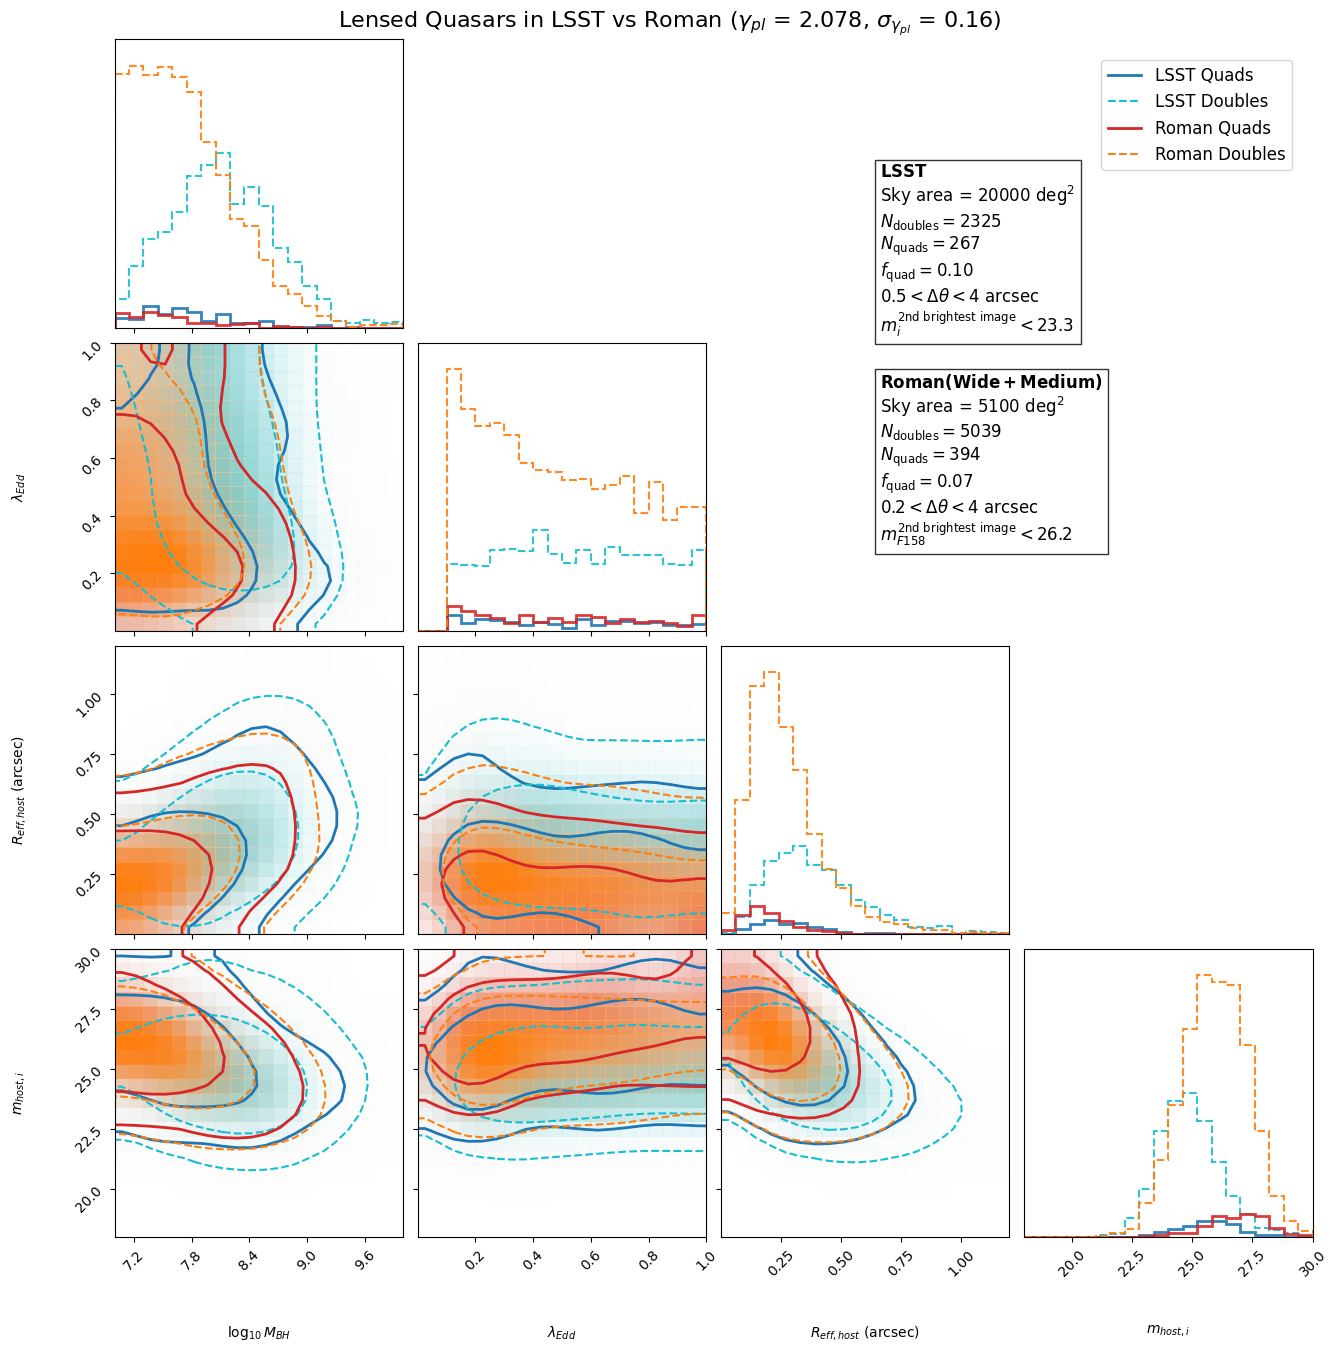

In [195]:
# --- PHYSICAL CASE 3: SOURCE PROPERTIES ---
# Using i-band as a baseline for comparison
params = ['black_hole_mass_exponent', 'eddington_ratio', 'host_light_R_eff_arcsec', 'unlensed_host_mag_i']
latex_labels = [r'$\log_{10} M_{BH}$', r'$\lambda_{Edd}$', r'$R_{eff, host}$ (arcsec)', r'$m_{host, i}$']

range_vals = {
    'black_hole_mass_exponent': (7, 10),
    'eddington_ratio': (0, 1.0),
    'host_light_R_eff_arcsec': (0, 1.2),
    'unlensed_host_mag_i': (18, 30),
}

figure = plt.figure(figsize=(14, 14))

handles = []
labels = []


color_map = {
    "LSST": {"quads": "tab:blue", "doubles": "tab:cyan"},
    "Roman":   {"quads": "tab:red",  "doubles": "tab:orange"},
}

for survey in survey_stats_dict.keys():
    sub_catalog = survey_stats_dict[survey]["detailed_lensed_quasar_catalog"].copy()

    sub_catalog_doubles = sub_catalog[sub_catalog['num_images'] == 2]
    sub_catalog_quads = sub_catalog[sub_catalog['num_images'] == 4]


    # quads 
    c_quad = color_map[survey]["quads"]
    data_quads = np.array([sub_catalog_quads[param] for param in params]).T

    if len(data_quads) > 0:
        corner.corner(
            data_quads,
            range=[range_vals[param] for param in params],
            labels=latex_labels,
            color=c_quad,
            fig=figure,
            plot_datapoints=False,
            # using density=True makes distributions comparable even if total counts differ
            hist_kwargs={"density": False, "histtype": "step", "linewidth": 2, "alpha": 0.9},
            contour_kwargs={"linewidths": 2}, 
            smooth=2,
            no_fill_contours=True,
            levels=[0.68, 0.95],
        )
        # Add Handle for Quads
        handles.append(mlines.Line2D([], [], color=c_quad, linewidth=2, label=f'{survey} Quads'))


    # doubles 
    c_double = color_map[survey]["doubles"]
    data_doubles = np.array([sub_catalog_doubles[param] for param in params]).T

    if len(data_doubles) > 0:
        corner.corner(
            data_doubles,
            range=[range_vals[param] for param in params],
            labels=latex_labels,
            color=c_double,
            fig=figure,
            plot_datapoints=False,
            # Dashed lines for doubles to add extra visual distinction
            hist_kwargs={"density": False, "histtype": "step", "linewidth": 1.5, "linestyle": "--", "alpha": 0.9},
            contour_kwargs={"linewidths": 1.5, "linestyles": "--"}, 
            smooth=2,
            no_fill_contours=True,
            levels=[0.68, 0.95],
        )
        # Add Handle for Doubles
        handles.append(mlines.Line2D([], [], color=c_double, linestyle='--', linewidth=1.5, label=f'{survey} Doubles'))

# append the number/cuts information text in empty space with latex formatting
# LSST Survey String
lsst_str = '\n'.join((
    fr'$\bf{{{survey_stats_dict["LSST"]["name"]}}}$',
    fr'Sky area = {survey_stats_dict["LSST"]["sky_area_deg2"]} deg$^2$',
    fr'$N_{{\mathrm{{doubles}}}}={survey_stats_dict["LSST"]["num_doubles"]}$',
    fr'$N_{{\mathrm{{quads}}}}={survey_stats_dict["LSST"]["num_quads"]}$',
    fr'$f_{{\mathrm{{quad}}}}={survey_stats_dict["LSST"]["quad_fraction"]:.2f}$',
    fr'${survey_stats_dict["LSST"]["min_image_separation"]} < \Delta\theta < {survey_stats_dict["LSST"]["max_image_separation"]}$ arcsec',
    fr'$m^{{\mathrm{{2nd\ brightest\ image}}}}_{{i}} < {survey_stats_dict["LSST"]["second_brightest_image_cut"]["i"]}$',
))

# Roman Survey String
roman_str = '\n'.join((
    fr'$\bf{{{survey_stats_dict["Roman"]["name"]}}}$',
    fr'Sky area = {survey_stats_dict["Roman"]["sky_area_deg2"]} deg$^2$',
    fr'$N_{{\mathrm{{doubles}}}}={survey_stats_dict["Roman"]["num_doubles"]}$',
    fr'$N_{{\mathrm{{quads}}}}={survey_stats_dict["Roman"]["num_quads"]}$',
    fr'$f_{{\mathrm{{quad}}}}={survey_stats_dict["Roman"]["quad_fraction"]:.2f}$',
    fr'${survey_stats_dict["Roman"]["min_image_separation"]} < \Delta\theta < {survey_stats_dict["Roman"]["max_image_separation"]}$ arcsec',
    fr'$m^{{\mathrm{{2nd\ brightest\ image}}}}_{{F158}} < {survey_stats_dict["Roman"]["second_brightest_image_cut"]["F158"]}$',
))

figure.text(0.65, 0.75, lsst_str, fontsize=12, color='black', bbox=dict(facecolor='white', alpha=0.8, edgecolor='black'))
figure.text(0.65, 0.60, roman_str, fontsize=12, color='black', bbox=dict(facecolor='white', alpha=0.8, edgecolor='black'))




# legend
figure.legend(handles=handles, loc='upper right', fontsize=12, bbox_to_anchor=(0.95, 0.95))
figure.suptitle(f'Lensed Quasars in LSST vs Roman ($\\gamma_{{pl}}$ = 2.078, $\\sigma_{{\\gamma_{{pl}}}}$ = 0.16)', fontsize=16)

## Catalog for TD Cosmography

In [ ]:
# -----------------------------------------------------------------------------------------------------------------------------
# --- System Properties ---
# 'z_S', 'z_D', 'theta_E_arcsec', 
# 'max_time_delay_days', 
# 'num_images', 

# --- Point Source (AGN) ---
# 'x_ps_position_arcsec',
# 'y_ps_position_arcsec',
# 'unlensed_ps_mag_<band>' for all bands,
# 'faintest_image_ps_mag_<band>' for all bands,
# 'second_brightest_image_ps_mag_<band>' for all bands,
# 'brightest_image_ps_mag_<band>' for all bands,
# 'lensed_ps_mag_<band>_<image#>' for all bands (brightest to faintest),
# 'time_delay_days_<image#>',           # (list of time delays for all images with respect to the straight line arrival time)
# 'ps_magnification_<image#>' (brightest to faintest),
# 'x_ps_image_positions_arcsec_<image#>',
# 'y_ps_image_positions_arcsec_<image#>',
# 'black_hole_mass_exponent', (in units of log_10 M_sun)
# 'eddington_ratio',

# --- Host Galaxy (Source) Light [SERSIC] ---
# 'x_host_position_arcsec',
# 'y_host_position_arcsec',
# 'unlensed_host_mag_<band>' for all bands,
# 'lensed_host_mag_<band>' for all bands,
# 'host_light_R_eff_arcsec',
# 'host_light_n_sersic',
# 'host_light_e1',
# 'host_light_e2',
# 'host_light_ellipticity',            # (computes as sqrt(e1^2 + e2^2))
# 'host_light_position_angle_deg',     # (computes as 0.5 * arctan2(e2, e1))

# --- Deflector Light (Lens Galaxy) [SERSIC] ---
# 'deflector_mag_<band>' for all bands,
# 'deflector_light_R_eff_arcsec',
# 'deflector_light_n_sersic',
# 'deflector_light_e1',
# 'deflector_light_e2',
# 'deflector_light_ellipticity',        # (computes as sqrt(e1^2 + e2^2))
# 'deflector_light_position_angle_deg', # (allows light/mass misalignment, computed as 0.5 * arctan2(e2, e1))
# 'deflector_light_axis_ratio',         # (q_light = (1 - e_light)/(1 + e_light))
# 'x_deflector_light_position_arcsec',  # (if light center differs from mass center)
# 'y_deflector_light_position_arcsec',  # (if light center differs from mass center)

# --- Deflector Mass (Lens Galaxy) [PEMD + SHEAR] ---
# 'x_deflector_mass_position_arcsec',
# 'y_deflector_mass_position_arcsec',
# 'deflector_stellar_mass',
# 'deflector_pl_slope',                 # (gamma_pl)
# 'deflector_velocity_dispersion',      # (sigma_v_D)
# 'deflector_mass_e1',                  # (e1_mass)
# 'deflector_mass_e2',                  # (e2_mass)
# 'deflector_mass_ellipticity',         # (e_mass = sqrt(e1_mass^2 + e2_mass^2))
# 'deflector_mass_axis_ratio',          # (q_mass = (1 - e_mass)/(1 + e_mass))
# 'deflector_mass_position_angle_deg',  # (phi_mass = 0.5 * arctan2(e2_mass, e1_mass))
# 'external_shear_gamma1',              # (gamma1 = gamma_ext * cos(2*phi_ext))
# 'external_shear_gamma2',              # (gamma2 = gamma_ext * sin(2*phi_ext))
# 'external_shear_amplitude',           # (gamma_ext = sqrt(gamma1^2 + gamma2^2))
# 'external_shear_position_angle_deg',  # (phi_ext = 0.5 * arctan2(gamma2, gamma1))
# 'external_convergence',               # (kappa_ext)

# -----------------------------------------------------------------------------------------------------------------------------

all_bands = ['g', 'r', 'i', 'z', 'y', 'F062', 'F087', 'F106', 'F129', 'F158', 'F184', 'F146', 'F213']
max_num_images = 4 # Assuming a maximum of 4 images (quad)

for survey in survey_stats_dict.keys():

    # -------------------------------------------------------------------------
    # Initialize table_dict
    # -------------------------------------------------------------------------
    table_dict = {
        # --- System Properties ---
        "z_S": [],
        "z_D": [],
        "theta_E_arcsec": [],
        "max_time_delay_days": [],
        "num_images": [],

        # --- Point Source (AGN) - Single Values ---
        "x_ps_position_arcsec": [],
        "y_ps_position_arcsec": [],
        "black_hole_mass_exponent": [],
        "eddington_ratio": [],

        # --- Host Galaxy (Source) Light [SERSIC] ---
        "x_host_position_arcsec": [],
        "y_host_position_arcsec": [],
        "host_light_R_eff_arcsec": [],
        "host_light_n_sersic": [],
        "host_light_e1": [],
        "host_light_e2": [],
        "host_light_ellipticity": [],
        "host_light_position_angle_deg": [],

        # --- Deflector Light (Lens Galaxy) [SERSIC] ---
        "deflector_light_R_eff_arcsec": [],
        "deflector_light_n_sersic": [],
        "deflector_light_e1": [],
        "deflector_light_e2": [],
        "deflector_light_ellipticity": [],
        "deflector_light_axis_ratio": [],
        "deflector_light_position_angle_deg": [],
        "x_deflector_light_position_arcsec": [],
        "y_deflector_light_position_arcsec": [],

        # --- Deflector Mass (Lens Galaxy) [PEMD + SHEAR] ---
        "x_deflector_mass_position_arcsec": [],
        "y_deflector_mass_position_arcsec": [],
        "deflector_stellar_mass": [],
        "deflector_pl_slope": [],               
        "deflector_velocity_dispersion": [],
        "deflector_mass_e1": [],    
        "deflector_mass_e2": [],
        "deflector_mass_ellipticity": [],        
        "deflector_mass_axis_ratio": [],         
        "deflector_mass_position_angle_deg": [], 
        "external_shear_gamma1": [],              
        "external_shear_gamma2": [],
        "external_shear_amplitude": [],          
        "external_shear_position_angle_deg": [], 
        "external_convergence": [],              
    }

    # --- Initialize Band-Dependent Keys ---
    for band in all_bands:
        table_dict[f"unlensed_ps_mag_{band}"] = []
        table_dict[f"faintest_image_ps_mag_{band}"] = []
        table_dict[f"second_brightest_image_ps_mag_{band}"] = []
        table_dict[f"brightest_image_ps_mag_{band}"] = []
        
        table_dict[f"unlensed_host_mag_{band}"] = []
        table_dict[f"lensed_host_mag_{band}"] = []
        
        table_dict[f"deflector_mag_{band}"] = []

    # --- Initialize Image-Dependent Keys (Geometry & Time) ---
    for img_num in range(1, max_num_images + 1):
        # Time delays and positions are generally band-independent in macro models
        table_dict[f"time_delay_days_{img_num}"] = []
        table_dict[f"ps_magnification_{img_num}"] = []
        table_dict[f"x_ps_image_positions_arcsec_{img_num}"] = []
        table_dict[f"y_ps_image_positions_arcsec_{img_num}"] = []

        # Lensed PS magnitudes depend on BOTH band and image number
        for band in all_bands:
            table_dict[f"lensed_ps_mag_{band}_{img_num}"] = []

    # -------------------------------------------------------------------------
    # Populate properties
    # -------------------------------------------------------------------------
    
    quasar_lens_population = survey_stats_dict[survey]["quasar_lens_population"]

    for lens_system in quasar_lens_population:

        source_index = 0  # assuming single source per lens system
        source_class = lens_system.source(source_index)
        deflector_class = lens_system.deflector
        ps_class = source_class._source._point_source
        es_class = source_class._source._extended_source
        
        # --- System ---
        table_dict["z_S"].append(lens_system.source_redshift_list[source_index])
        table_dict["z_D"].append(lens_system.deflector_redshift)
        table_dict["theta_E_arcsec"].append(lens_system.einstein_radius[source_index])
        table_dict["num_images"].append(lens_system.image_number[source_index])

        # --- Time Delay ---
        arrival_times = lens_system.point_source_arrival_times()[source_index]  # in days
        max_time_delay = np.max(arrival_times) - np.min(arrival_times)
        table_dict["max_time_delay_days"].append(max_time_delay)

        # --- Point Source (AGN) ---
        x_ps, y_ps = source_class.point_source_position
        table_dict["x_ps_position_arcsec"].append(x_ps)
        table_dict["y_ps_position_arcsec"].append(y_ps)
        table_dict["black_hole_mass_exponent"].append(ps_class.source_dict.get("black_hole_mass_exponent", np.nan))
        table_dict["eddington_ratio"].append(ps_class.source_dict.get("eddington_ratio", np.nan))

        # --- Host Galaxy (Source) Light [SERSIC] ---
        x_host, y_host = es_class.extended_source_position
        table_dict["x_host_position_arcsec"].append(x_host)
        table_dict["y_host_position_arcsec"].append(y_host)
        table_dict["host_light_R_eff_arcsec"].append(es_class.angular_size)
        table_dict["host_light_n_sersic"].append(es_class._n_sersic)
        e1_host, e2_host = es_class.ellipticity
        e_host = np.sqrt(e1_host**2 + e2_host**2)
        q_host = (1 - e_host) / (1 + e_host)
        phi_host = 0.5 * np.degrees(np.arctan2(e2_host, e1_host))
        table_dict["host_light_e1"].append(e1_host)
        table_dict["host_light_e2"].append(e2_host)
        table_dict["host_light_ellipticity"].append(e_host)
        table_dict["host_light_position_angle_deg"].append(phi_host)
        

        # compute deflector light/mass properties
        e1_light, e2_light, e1_mass, e2_mass = lens_system.deflector_ellipticity()
        e_mass = np.sqrt(e1_mass**2 + e2_mass**2)
        q_mass = (1 - e_mass) / (1 + e_mass)
        phi_mass = 0.5 * np.degrees(np.arctan2(e2_mass, e1_mass))
        e_light = np.sqrt(e1_light**2 + e2_light**2)
        q_light = (1 - e_light) / (1 + e_light)
        phi_light = 0.5 * np.degrees(np.arctan2(e2_light, e1_light))

        # compute external shear/convergence
        kappa_ext, gamma1_ext, gamma2_ext = lens_system.los_linear_distortions
        gamma_ext = np.sqrt(gamma1_ext**2 + gamma2_ext**2)
        phi_ext = 0.5 * np.degrees(np.arctan2(gamma2_ext, gamma1_ext))

        # positions
        x_pos_deflector_mass, y_pos_deflector_mass = lens_system.deflector_position
        x_pos_deflector_light, y_pos_deflector_light = lens_system.deflector_position


        # --- Deflector Mass (PEMD + EXTERNAL SHEAR) ---
        table_dict["deflector_velocity_dispersion"].append(lens_system.deflector_velocity_dispersion())
        table_dict["deflector_mass_e1"].append(e1_mass)
        table_dict["deflector_mass_e2"].append(e2_mass)
        table_dict["deflector_mass_ellipticity"].append(e_mass)
        table_dict["deflector_mass_axis_ratio"].append(q_mass)
        table_dict["deflector_mass_position_angle_deg"].append(phi_mass)
        table_dict["deflector_pl_slope"].append(deflector_class.halo_properties.get("gamma_pl", np.nan))
        table_dict["deflector_stellar_mass"].append(lens_system.deflector_stellar_mass())
        table_dict["x_deflector_mass_position_arcsec"].append(x_pos_deflector_mass)
        table_dict["y_deflector_mass_position_arcsec"].append(y_pos_deflector_mass)
        table_dict["external_convergence"].append(kappa_ext)
        table_dict["external_shear_gamma1"].append(gamma1_ext)
        table_dict["external_shear_gamma2"].append(gamma2_ext)
        table_dict["external_shear_amplitude"].append(gamma_ext)
        table_dict["external_shear_position_angle_deg"].append(phi_ext)

        # --- Deflector Light ---
        table_dict["x_deflector_light_position_arcsec"].append(x_pos_deflector_light)
        table_dict["y_deflector_light_position_arcsec"].append(y_pos_deflector_light)
        table_dict["deflector_light_e1"].append(e1_light)
        table_dict["deflector_light_e2"].append(e2_light)
        table_dict["deflector_light_ellipticity"].append(e_light)
        table_dict["deflector_light_axis_ratio"].append(q_light)
        table_dict["deflector_light_position_angle_deg"].append(phi_light)
        table_dict["deflector_light_R_eff_arcsec"].append(lens_system.deflector.angular_size_light)
        table_dict["deflector_light_n_sersic"].append(deflector_class._deflector._deflector_dict.get("n_sersic", np.nan))

        num_images = lens_system.image_number[source_index]
        
        # --- Band-Dependent Properties ---
        for band in all_bands:
            # Unlensed PS Magnitude
            unlensed_ps_mag = lens_system.point_source_magnitude(band=band, lensed=False)[source_index]
            table_dict[f"unlensed_ps_mag_{band}"].append(unlensed_ps_mag)

            # Lensed PS Magnitudes
            lensed_ps_mags = lens_system.point_source_magnitude(band=band, lensed=True)[source_index]

            # Faintest and Second Brightest Image Magnitudes
            faintest_image_ps_mag = np.max(lensed_ps_mags)
            second_brightest_image_ps_mag = np.sort(lensed_ps_mags)[1]
            brightest_image_ps_mag = np.min(lensed_ps_mags)
            table_dict[f"faintest_image_ps_mag_{band}"].append(faintest_image_ps_mag)
            table_dict[f"second_brightest_image_ps_mag_{band}"].append(second_brightest_image_ps_mag)
            table_dict[f"brightest_image_ps_mag_{band}"].append(brightest_image_ps_mag)

            # Unlensed and Lensed Host Magnitudes
            unlensed_host_mag = lens_system.extended_source_magnitude(band=band, lensed=False)[source_index]
            lensed_host_mag = lens_system.extended_source_magnitude(band=band, lensed=True)[source_index]
            table_dict[f"unlensed_host_mag_{band}"].append(unlensed_host_mag)
            table_dict[f"lensed_host_mag_{band}"].append(lensed_host_mag)

            # Deflector Magnitudes
            deflector_mag = lens_system.deflector_magnitude(band=band)
            table_dict[f"deflector_mag_{band}"].append(deflector_mag)

            # Lensed PS Magnitudes for each image
            for img_num in range(1, max_num_images + 1):
                if img_num <= num_images:
                    table_dict[f"lensed_ps_mag_{band}_{img_num}"].append(lensed_ps_mags[img_num-1])
                else:
                    table_dict[f"lensed_ps_mag_{band}_{img_num}"].append(np.nan)
        
        # --- Image-Dependent Properties ---
        ps_magnifications = lens_system.point_source_magnification()[source_index]
        x_image_positions, y_image_positions = lens_system.point_source_image_positions()[source_index]
        arrival_times = lens_system.point_source_arrival_times()[source_index]  # in days

        for img_num in range(1, max_num_images + 1):
            if img_num <= num_images:
                table_dict[f"time_delay_days_{img_num}"].append(arrival_times[img_num-1])
                table_dict[f"ps_magnification_{img_num}"].append(ps_magnifications[img_num-1])
                table_dict[f"x_ps_image_positions_arcsec_{img_num}"].append(x_image_positions[img_num-1])
                table_dict[f"y_ps_image_positions_arcsec_{img_num}"].append(y_image_positions[img_num-1])
            else:
                table_dict[f"time_delay_days_{img_num}"].append(np.nan)
                table_dict[f"ps_magnification_{img_num}"].append(np.nan)
                table_dict[f"x_ps_image_positions_arcsec_{img_num}"].append(np.nan)
                table_dict[f"y_ps_image_positions_arcsec_{img_num}"].append(np.nan)
    # Create astropy table
    detailed_lensed_quasar_catalog = Table(table_dict)
    survey_stats_dict[survey]["detailed_lensed_quasar_catalog"] = detailed_lensed_quasar_catalog

/home/paras/sharmapyenv/lib64/python3.12/site-packages/lenstronomy/LensModel/Solver/epl_shear_solver.py:245: RuntimeWarning: invalid value encountered in multiply
  + stuff[1] * 1j
/home/paras/sharmapyenv/lib64/python3.12/site-packages/lenstronomy/LensModel/Solver/epl_shear_solver.py:245: RuntimeWarning: invalid value encountered in multiply
  + stuff[1] * 1j


In [ ]:
lsst_catalog = survey_stats_dict['LSST']["detailed_lensed_quasar_catalog"]
roman_catalog = survey_stats_dict['Roman']["detailed_lensed_quasar_catalog"]

lsst_catalog_TD_lenses = lsst_catalog[lsst_catalog['unlensed_ps_mag_i'] < 22]
roman_catalog_TD_lenses = roman_catalog[roman_catalog['unlensed_ps_mag_i'] < 22]

# numbers
print("----- Lensed Quasar Numbers (m_i < 22) -----")
print(f"Number of LSST TD lenses (m_i < 22): {len(lsst_catalog_TD_lenses)}")
print(f"Number of LSST TD Quads (m_i < 22): {len(lsst_catalog_TD_lenses[lsst_catalog_TD_lenses['num_images'] == 4])}")
print()
print(f"Number of Roman TD lenses (m_i < 22): {len(roman_catalog_TD_lenses)}")
print(f"Number of Roman TD Quads (m_i < 22): {len(roman_catalog_TD_lenses[roman_catalog_TD_lenses['num_images'] == 4])}")
print() 

# %
print("----- Lensed Quasar Percentages (m_i < 22) -----")
print(f"% of LSST TD lenses (m_i < 22): {100 * len(lsst_catalog_TD_lenses) / len(lsst_catalog):.2f}%")
print(f"% of LSST TD Quads (m_i < 22): {100 * len(lsst_catalog_TD_lenses[lsst_catalog_TD_lenses['num_images'] == 4]) / len(lsst_catalog):.2f}%")
print()
print(f"% of Roman TD lenses (m_i < 22): {100 * len(roman_catalog_TD_lenses) / len(roman_catalog):.2f}%")
print(f"% of Roman TD Quads (m_i < 22): {100 * len(roman_catalog_TD_lenses[roman_catalog_TD_lenses['num_images'] == 4]) / len(roman_catalog):.2f}%")

----- Lensed Quasar Numbers (m_i < 22) -----
Number of LSST TD lenses (m_i < 22): 1264
Number of LSST TD Quads (m_i < 22): 36

Number of Roman TD lenses (m_i < 22): 621
Number of Roman TD Quads (m_i < 22): 11

----- Lensed Quasar Percentages (m_i < 22) -----
% of LSST TD lenses (m_i < 22): 47.61%
% of LSST TD Quads (m_i < 22): 1.36%

% of Roman TD lenses (m_i < 22): 11.15%
% of Roman TD Quads (m_i < 22): 0.20%


In [174]:
survey_stats_dict['LSST']["detailed_lensed_quasar_catalog"]['ps_magnification_1', 'ps_magnification_2', 'ps_magnification_3', 'ps_magnification_4']

ps_magnification_1,ps_magnification_2,ps_magnification_3,ps_magnification_4
float64,float64,float64,float64
1.6075730592500348,-0.33904097620188534,nan,nan
2.914251154374827,-1.7251056323559752,nan,nan
2.5603074338453906,-1.776495816698318,nan,nan
2.075585836792298,-1.9025982460529014,nan,nan
4.458430982856528,18.493620054797766,-15.38253355670432,-4.774161035107499
2.400092644947573,-1.7721361248458491,nan,nan
6.96730239960804,-1.3557840276712085,nan,nan
1.5019958774573376,-0.058373663780731916,nan,nan
3.360914749839325,4.275014143491191,-3.529681717751448,-1.5001388295597522


In [ ]:
# survey_stats_dict['LSST']["detailed_lensed_quasar_catalog"].write('lensed_quasar_catalog_LSST.fits', format='fits', overwrite=True)
# survey_stats_dict['Roman']["detailed_lensed_quasar_catalog"].write('lensed_quasar_catalog_Roman.fits', format='fits', overwrite=True)

In [115]:
example_lens = survey_stats_dict['LSST']["quasar_lens_population"][10]
example_deflector = example_lens.deflector
example_source = example_lens.source(0)
example_ps_class = example_source._source._point_source
example_es_class = example_source._source._extended_source
example_ps_class_dict = example_ps_class.__dict__
example_es_class_dict = example_es_class.__dict__

In [125]:
print('example_lens.__dict__', example_lens.__dict__)
print('example_ps_class_dict', example_ps_class_dict)
print('example_es_class_dict', example_es_class_dict)

example_lens.__dict__ {'deflector': <slsim.Deflectors.deflector.Deflector object at 0x7fe4ed986ab0>, 'multi_plane': None, 'shear': True, 'convergence': True, '_source': [<slsim.Sources.source.Source object at 0x7fe4edc74470>], 'source_number': 1, 'max_redshift_source_class': <slsim.Sources.source.Source object at 0x7fe4edc74470>, '_max_redshift_source_index': 0, 'los_class': <slsim.LOS.los_individual.LOSIndividual object at 0x7fe4ed984680>, 'cosmo': FlatLambdaCDM(name=None, H0=<Quantity 70. km / (Mpc s)>, Om0=0.3, Tcmb0=<Quantity 0. K>, Neff=3.04, m_nu=None, Ob0=0.0), '_lens_equation_solver': 'lenstronomy_analytical', '_magnification_limit': 0.01, '_lens_cosmo': <lenstronomy.Cosmo.lens_cosmo.LensCosmo object at 0x7fe4ed987680>, '_use_jax': True, '_ps_image_position_list': [(array([-0.68089336,  0.69520163]), array([ 1.63008744, -0.59949146]))], '_kwargs_lens': [{'theta_E': np.float64(1.3236805184228968), 'gamma': np.float64(2.3085242679830573), 'center_x': np.float64(-0.022499118891110

In [ ]:
example_lens